In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp

# Normalizing flows

Constructing normalizing flows easily using the inverse interpreter!

In [2]:
input_dim = 2

In [3]:
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
# Mixture of Gaussians target distribution

target_samples1 = p.sample(jax.random.PRNGKey(0), (1000,)) + 5.0
target_samples2 = p.sample(jax.random.PRNGKey(1), (1000,)) - 5.0
xs = jnp.concatenate([target_samples1, target_samples2], axis=0)


### Affine flows

We have a coupling MLP combined with an affine bijector.

In [5]:

def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jnp.exp(scale) + 0.5

    return loc + scale*x


bijector_dim = 2*(input_dim // 2)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim), 
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim)])
    return nn(x)

params = forward.init(jax.random.PRNGKey(0), jnp.zeros((input_dim)))

# Parameterized invertibe transformation
T = forward.apply

In [6]:
T(params, jnp.ones((1, input_dim)))

Array([[2.376, 8.434]], dtype=float32)

In [7]:
jaxpr = jax.make_jaxpr(lambda x: T(params, x))(jnp.ones((1, input_dim)))

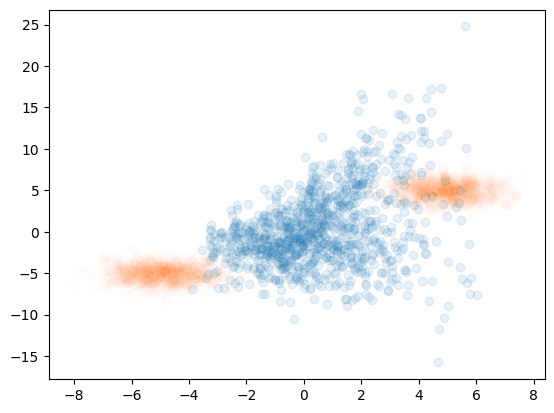

In [8]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [9]:
x = jnp.ones((10,input_dim))
y = T(params, x)


q._inv_and_logdet(y)

(Array([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]], dtype=float32),
 Array([-2.356, -2.356, -2.356, -2.356, -2.356, -2.356, -2.356, -2.356,
        -2.356, -2.356], dtype=float32))

In [10]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [11]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

9.053237
3.8983507
3.7159214
3.6053824
3.556729


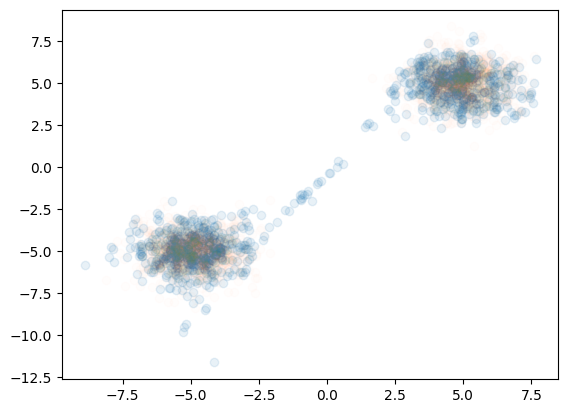

In [12]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))


plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

## Spline flows

In [13]:
input_dim = 4
from functools import partial
@partial(jax.vmap, in_axes=(None, 0))
def spline_bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -15., range_max_y=15.)

num_bins = 6
bijector_dim = (3 * num_bins)
split_dim = 3

@hk.without_apply_rng
@hk.transform
def forward(x):
    nn = hk.Sequential([CouplingMLP(1, spline_bijector, bijector_dim),Flip(), CouplingMLP(1, spline_bijector, bijector_dim), Flip()])
    return nn(x)

init, apply = forward.init, forward.apply
params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)))
T = apply

In [14]:
y = apply(params, jnp.ones((input_dim)))

q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

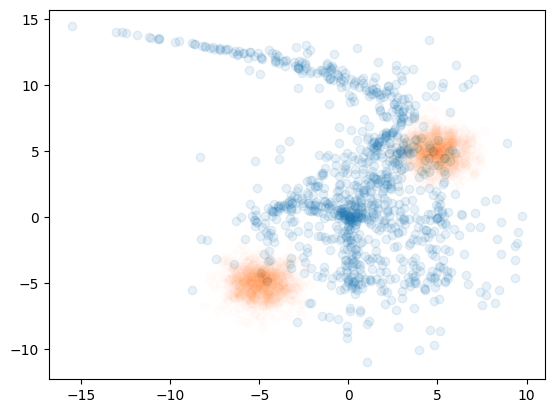

In [15]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [16]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [19]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

7.3965454
3.55323
3.5343904
3.4895754
3.43909


In [20]:
q = TransformedDistribution(p, lambda x: apply(params, x))
samples = q.sample(jax.random.PRNGKey(0), sample_shape=(1000,))

(-10.0, 10.0)

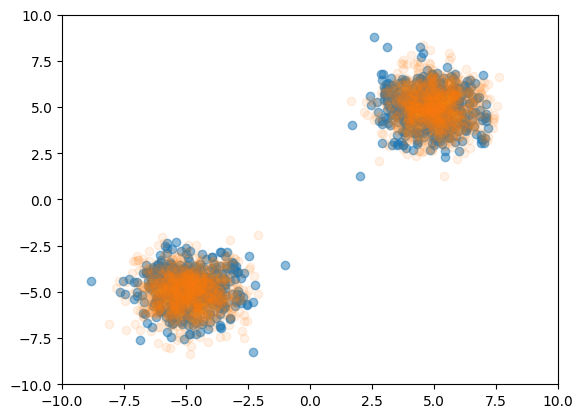

In [21]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Gaussianization flow

Here we do not even need any neural nets!

In [26]:
from probjax.nn.helpers import Rotate

spline_based = jax.vmap(spline_bijector, in_axes=(-1, -1))

@hk.without_apply_rng
@hk.transform
def f(x):
    r1 = Rotate(jax.random.PRNGKey(0), 2)
    r2 = Rotate(jax.random.PRNGKey(1), 2)
    r3 = Rotate(jax.random.PRNGKey(2), 2)

    params1 = hk.get_parameter("params_spline1", shape=(12,2), init=hk.initializers.RandomNormal(0.1)   )
    params2 = hk.get_parameter("params_spline2", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )
    params3 = hk.get_parameter("params_spline3", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )
    params4 = hk.get_parameter("params_spline4", shape=(12,2), init=hk.initializers.RandomNormal(0.1)  )

    x1 = spline_based(params1, x)
    x2 = r1(x1)
    x3 = spline_based(params2, x2)
    x4 = r2(x3)
    x5 = spline_based(params3, x4)
    x6 = r3(x5)
    x7 = spline_based(params4, x6)

    return x7

init, apply = f.init, f.apply

params = init(jax.random.PRNGKey(0), jnp.ones((1,input_dim,)))

T = apply

In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

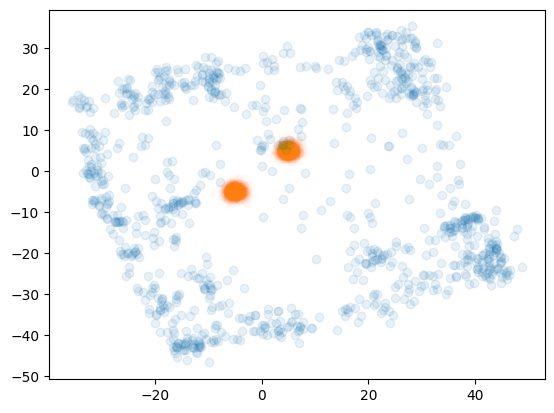

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [ ]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [ ]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

10.615106
4.299103
3.7469084
3.69427
3.6351552


In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

(-10.0, 10.0)

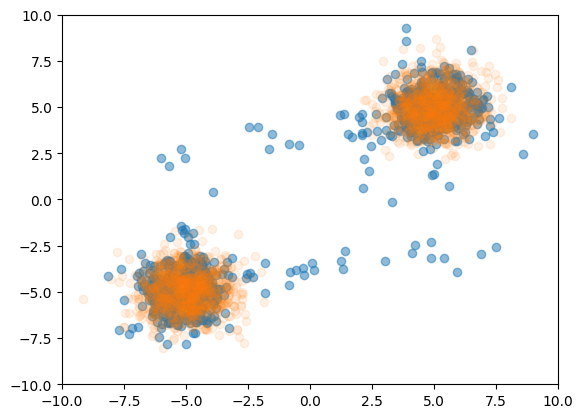

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

plt.xlim(-10, 10)
plt.ylim(-10, 10)

In [ ]:
from probjax.nn.bijective import learnable_mixture_cdf

In [ ]:
from probjax.nn.helpers import Rotate, rotate
# Affine can only be Gaussian!



@hk.without_apply_rng
@hk.transform
def f(x):

    params1 = hk.get_parameter("params_affine1", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params2 = hk.get_parameter("params_affine2", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params3 = hk.get_parameter("params_affine3", shape=(2,50), init=hk.initializers.RandomNormal(0.1))
    params4 = hk.get_parameter("params_affine4", shape=(2,50), init=hk.initializers.RandomNormal(0.1))

    rot1 = hk.get_parameter("r1", shape=(2,2),init=hk.initializers.RandomNormal(0.1))
    rot2 = hk.get_parameter("r2", shape=(2,2),init=hk.initializers.RandomNormal(0.1))
    rot3 = hk.get_parameter("r3", shape=(2,2),init=hk.initializers.RandomNormal(0.1))

    rot1 = jnp.linalg.qr(rot1)[0]
    rot2 = jnp.linalg.qr(rot2)[0]
    rot3 = jnp.linalg.qr(rot3)[0]

    x1 = learnable_mixture_cdf(params1, x)
    x2 = rotate(rot1, x1)
    x3 = learnable_mixture_cdf(params2, x2)
    x4 = rotate(rot2, x3)
    x5 = learnable_mixture_cdf(params3, x4)
    x6 = rotate(rot3, x5)
    x7 = learnable_mixture_cdf(params4, x6)

    return x7

init, apply = f.init, f.apply

params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)))

T = apply

In [ ]:
learnable_mixture_cdf(params["~"]["params_affine1"], 0.4*jnp.ones((input_dim)))

Array([0.666, 0.727], dtype=float32)

In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

In [ ]:
samples

Array([[ 1.89 ,  1.194],
       [10.   ,  9.706],
       [10.   ,  5.744],
       ...,
       [ 5.008, 10.   ],
       [10.   , 10.   ],
       [ 4.321, 10.   ]], dtype=float32)

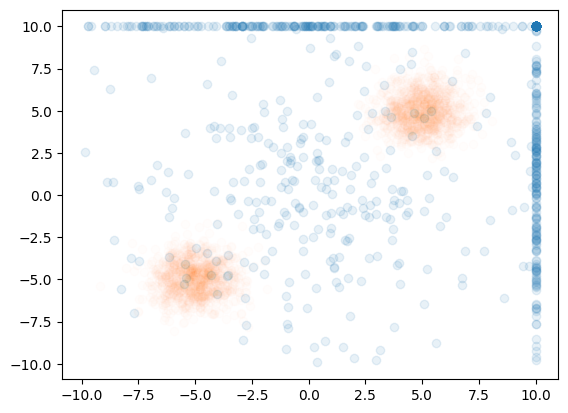

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

In [ ]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)

# Train
def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()

@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [ ]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 1000 == 0:
        print(loss)

7.7765713
4.035629
3.6147213
3.5648577
3.5141432


In [ ]:
q = TransformedDistribution(p, lambda x: T(params, x))
samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

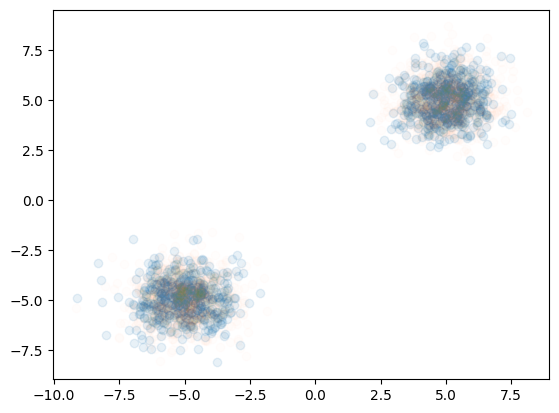

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.01)

# Continous normalizing flows

In [30]:
from probjax.utils.odeint import odeint
from probjax.nn.helpers import SinusoidalEmbedding#


def net(t, x):
    #print("Net", t,x)
    t = jnp.array(t).reshape(-1)
    t = SinusoidalEmbedding(4)(t)
    return hk.nets.MLP([50, 50, 2], activation=jnp.tanh)(jnp.concatenate([t, x], axis=-1))


init, f = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((2,)))

t = jnp.linspace(0, 1, 100)

def T(params, x):
    ys =  odeint(lambda t, x: f(params, t, x), x, jnp.linspace(0, 1, 100))
    return ys[-1]

q = TransformedDistribution(p, lambda x: T(params, x))

samples = q.sample(jax.random.PRNGKey(0 ), (1000,))
log_prob = q.log_prob(samples)

In [31]:
optimizer = adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, x):
    q = TransformedDistribution(p, lambda x: T(params, x))
    return -q.log_prob(x).mean()
    
@jax.jit
def step(params, opt_state, x):
    loss, g = jax.value_and_grad(loss_fn)(params, x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [32]:
for i in range(100):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (256,))
    params, opt_state, loss = step(params, opt_state, xs_batch)
    if i % 50 == 0:
        print(loss)

27.401188
3.720077


In [33]:

q = TransformedDistribution(p, lambda x: T(params, x))

samples = q.sample(jax.random.PRNGKey(0 ), (1000,))

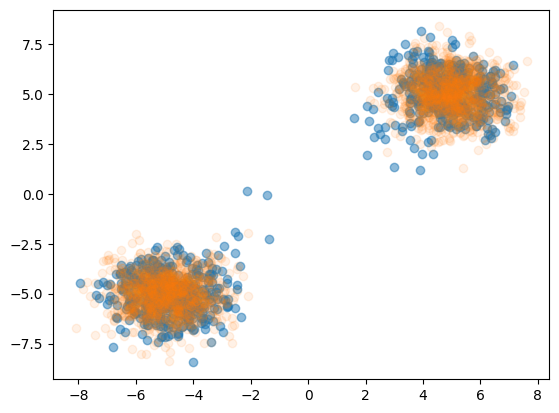

In [34]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)


# Flow matching

In [73]:
def f(x):

    hk.set_state("x", 1.0)
    hk.set_state("x", 2.0)
    return x

init, f = hk.without_apply_rng(hk.transform_with_state(f))
init(jax.random.PRNGKey(0), jnp.ones(1))

({}, {'~': {'x': 1.0}})

In [36]:

def conditional_flow_and_score_matching_loss(params,key, times, xs_source, xs_target,model_fn, mean_fn, std_fn, estimate_score = False):
    
    # Sample x_t
    eps = jax.random.normal(key, shape=xs_source.shape)
    xs_t = mean_fn(xs_source, xs_target, times) + std_fn(xs_source, xs_target, times) * eps
    
    # Compute u_t

    t = jnp.broadcast_to(times, xs_target.shape) # Pad to x shape for jax.grad -> x.shape
    std_fn_grad = jax.grad(lambda x_s, x_t, t: std_fn(x_s, x_t, t).sum(), argnums=2)
    mean_fn_grad = jax.grad(lambda x_s, x_t, t: mean_fn(x_s, x_t, t).sum(), argnums=2)
    u_t = std_fn_grad(xs_source, xs_target, t) * eps + mean_fn_grad(xs_source, xs_target, t)
        
    # Compute v_t
    if not estimate_score:
        v_t = model_fn(params, times, xs_t)

        # Compute loss
        loss = jnp.mean(jnp.sum((v_t - u_t)**2, axis=-1))
        
        return loss
    else:
        v_t, s_t = model_fn(params, times, xs_t)

        # Compute loss
        loss = jnp.mean(jnp.sum((v_t - u_t)**2, axis=-1))
        loss_score = jnp.mean(jnp.sum((s_t + 1/std_fn(xs_source, xs_target, times)* eps)**2, axis=-1))
        
        return loss, loss_score

    

In [37]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import SinusoidalEmbedding
from functools import partial
input_dim = 2
hidden_dim = 200
def net(t, x):
    t = jnp.array(t)
    t = SinusoidalEmbedding(hidden_dim)(t)
    
    h1_x = hk.Linear(hidden_dim)(x)
    h1_t = hk.Linear(hidden_dim)(t)
    h1 = jax.nn.swish(h1_x + h1_t) 
    h2 = hk.Linear(hidden_dim)(h1)
    h2_t = hk.Linear(hidden_dim)(t)
    h2 = jax.nn.swish(h2 + h2_t) + h1
    h3 = hk.Linear(hidden_dim)(h2)
    h3_t = hk.Linear(hidden_dim)(t)
    h3 = jax.nn.swish(h3 + h3_t) + h2
    h4_x = hk.Linear(hidden_dim)(h3)
    h4_t = hk.Linear(hidden_dim)(t)
    h4 = jax.nn.swish(h4_x + h4_t) + h3

    

    out = hk.Linear(input_dim)(h4)
    return out
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones((1,1)), jnp.ones((1,2)))

ts = jnp.linspace(0, 1, 200)

def drift(t, x, params):
    return forward(params, t, x)


In [38]:
# Conditional OT transprot
sigma = 1e-4
mean_fn = lambda x_source, x_target, t: t * x_target
std_fn = lambda x_source, x_target, t: (1 - (1-sigma)*t)
loss1 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [39]:
# Conditional OT transport 2
sigma = 1e-4
mean_fn = lambda x_source, x_target, t: t * x_target + (1-t) * x_source
std_fn = lambda x_source, x_target, t: jnp.array(sigma)
loss2 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [40]:
# Noisy OT transport
mean_fn = lambda x_source, x_target, t: t * x_target + (1-t) * x_source
std_fn = lambda x_source, x_target, t: jnp.sqrt(2*t * (1-t)) 
loss2_2 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [41]:
# Variance preserving conditional flow matching
sigma = 1e-4
mean_fn = lambda x_source, x_target, t: jnp.cos(jnp.pi / 2*t)*x_source + jnp.sin(jnp.pi / 2*t)*x_target
std_fn = lambda x_source, x_target, t: jnp.array(sigma)
loss3 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [84]:
# Encoding decoding flow
mean_fn = lambda x_source, x_target, t: jnp.where(t < 0.5, jnp.cos(jnp.pi*t)**2 * x_source, jnp.cos(jnp.pi*t)**2 * x_target)
std_fn = lambda x_source, x_target, t: jnp.sin(jnp.pi*t)**2
loss4 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [85]:
# Encoding decoding flow with dimensionality reduction
def mean_fn(x_source, x_target, t): 
    y = jnp.where(t < 0.5, jnp.cos(jnp.pi*t)**2 * x_source, jnp.cos(jnp.pi*t)**2 * x_target)
    return y
def std_fn(x_source, x_target, t):
    y =   jnp.sin(jnp.pi*t[...,0])**2
    y2 =  jnp.where(t[...,1] < 0.5, jnp.cos(jnp.pi*t[...,1])**2 ,0.)
    full = jnp.vstack([y, y2]).T
    return full

loss4_1 = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn)

In [68]:
sigma_min = 1e-2

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    key_source, key_time, key_loss = jax.random.split(key,3)
    xs_source = jax.random.normal(key_source, x1.shape)
    times = jax.random.uniform(key_time, (x1.shape[0], 1))
    
    return loss4_1(params, key_loss, times, xs_source, x1) 
    

optimizer = adam(1e-3)
opt_state = optimizer.init(params)
    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [69]:
for i in range(1000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, jax.random.PRNGKey(i + 10000),xs_batch)
    if i % 100 == 0:
        print(loss)

191.73851
25.42181
15.3619375
10.525986
10.939421
8.900307
9.485119
9.381041
9.189104
8.460065


In [28]:
def sample(params, key, shape):
    z0 = jax.random.normal(key, shape + (2,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 200), method="rk4")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [71]:
samples = sample(params, jax.random.PRNGKey(0), (1000,))

In [72]:
evolution = odeint(lambda t, x: drift(t, x, params), jax.random.normal(jax.random.PRNGKey(0), xs.shape), jnp.linspace(0,1, 1000), method="rk4")

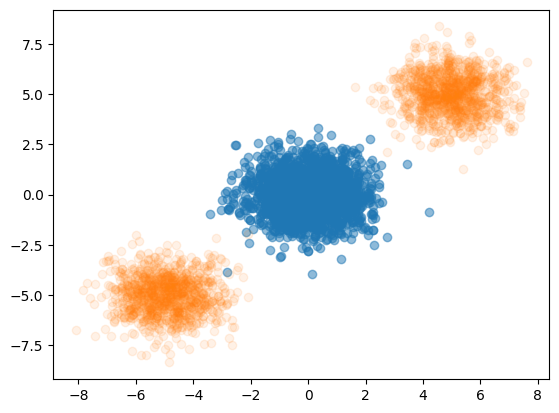

In [73]:
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

def update(i):
    ax.clear()
    ax.scatter(evolution[i,:,0], evolution[i,:,1], alpha=0.5)
    ax.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

ani = animation.FuncAnimation(fig, update, frames=range(0, 1019, 20))
HTML(ani.to_jshtml())

## Stochastic interpolants

Here we have

$$ x_t = I(t,x_0, x_1) + \gamma(t)z \qquad z \sim \mathcal{N}(0,I)$$

with $I(0, x_0, x_1) = x_0 \sim p(x_0)$, $I(1, x_0, x_1) = x_1 \sim p(x_1)$ and $\gamma(0) = \gamma(1) = 0$. By construction we have that realizations of this stochastic process are sampled from $p(x_0) at t=0$ and $p(x_1)$ at $t=1$. 

In continous time we have

$$ x_t ' = I(t,x_0, x_1) * N_t$$
where $N_t$ is a zero mean gaussian noise process with $\Sigma(N_t) = \gamma(t)**2 I$.

### Transport flows 

Here we just need the **transport equation** from $p(x_0)$ to $p(x_1)$, which we can get by
$$ b(t,x) = \mathbb{E} \left[ \partial_t I(t, x_0,x_1) + \gamma'(t)z | x_t = x \right]$$
which thus can be learned by

$$ \mathcal{L}[b] = \int_0^1 \mathbb{E}_{p(x_0)p(x_1)p(z)}\left[ 0.5 b(t, x_t)|^2 - (\partial_t I(t, x_0,x_1) + \gamma'(t)z ) \cdot b(t,x_t)    \right]dt$$


### Score matching

The score is given by

$$s(t, x) = \nabla_x p_t(x) = - \gamma^{-1}(t) \mathbb{E}(z | x_t = x)$$

and can thus be learned by

$$ \mathcal{L}[s] = \int_0^1 \mathbb{E}_{p(x_0)p(x_1)p(z)}\left[ 0.5 s(t, x_t)|^2  + \gamma^{-1}(t) + z * s(t, x_t)  \right]dt $$

### Relationship between transport and score matching

Be 
$$ v(t, x) = \mathbb{E}\left[ \partial_t I(t,x_0,x_1)|x_t=x  \right]$$
then 
$$ b(t,x) = v(t, x) + \gamma'(t)\gamma(t) s(t,x)$$


### Generative models

1) Probability flow
$$ \frac{d}{dt} X_t = b(t, X_t) $$
2) forward SDE
$$ dX_t^F = b^F(t, X_t)dt + \sqrt{2} \epsilon dW_t$$
for any $\epsilon > 0$ and $b^F(t,x) = b(t,x) + \epsilon s(t,x)$.

3) backward SDE
$$ dX_t^B = b^B(t, X_t)dt + \sqrt{2} \epsilon dW^B_t$$
for any $\epsilon > 0$ and $b^B(t,x) = b(t,x) - \epsilon s(t,x)$ and $W^B_t = - W_{1-t}$


This is equlvanet to the above, but also allows to estimate the SCORE!!! Which can then be transformed back to the density.

In [42]:
# Lets estiamte both the flow and the score function

from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import SinusoidalEmbedding
from functools import partial
input_dim = 2
hidden_dim = 200
def net(t, x):
    t = jnp.array(t)
    t = SinusoidalEmbedding(hidden_dim)(t)
    
    h1_x = hk.Linear(hidden_dim)(x)
    h1_t = hk.Linear(hidden_dim)(t)
    h1 = jax.nn.swish(h1_x + h1_t) 
    h2 = hk.Linear(hidden_dim)(h1)
    h2_t = hk.Linear(hidden_dim)(t)
    h2 = jax.nn.swish(h2 + h2_t) + h1
    h3 = hk.Linear(hidden_dim)(h2)
    h3_t = hk.Linear(hidden_dim)(t)
    h3 = jax.nn.swish(h3 + h3_t) + h2
    h4_x = hk.Linear(hidden_dim)(h3)
    h4_t = hk.Linear(hidden_dim)(t)
    h4 = jax.nn.swish(h4_x + h4_t) + h3

    

    v_t = hk.nets.MLP([hidden_dim,hidden_dim, input_dim])(h4)
    s_t = hk.nets.MLP([hidden_dim,hidden_dim, input_dim])(h4)
    return v_t, s_t
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones((1,1)), jnp.ones((1,2)))

ts = jnp.linspace(0, 1, 200)



In [43]:
# Conditional OT transport 2
mean_fn = lambda x_source, x_target, t: t * x_target + (1-t) * x_source
std_fn = lambda x_source, x_target, t: jnp.sqrt(2*t * (1-t))
loss = partial(conditional_flow_and_score_matching_loss, model_fn=forward, mean_fn=mean_fn, std_fn=std_fn, estimate_score=True)

In [44]:
sigma_min = 1e-2

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    key_source, key_time, key_loss = jax.random.split(key,3)
    xs_source = jax.random.normal(key_source, x1.shape)
    times = jax.random.uniform(key_time, (x1.shape[0], 1))
    
    loss_v, loss_s =  loss(params, key_loss, times, xs_source, x1) 
    return loss_v + loss_s
    

optimizer = adam(1e-3)
opt_state = optimizer.init(params)
    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [45]:
for i in range(1000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    params, opt_state, loss = step(params, opt_state, jax.random.PRNGKey(i + 10000),xs_batch)
    if i % 100 == 0:
        print(loss)

146.50943
64.20869
33.30001
34.880375
57.85881
41.44903
43.401756
31.113564
34.032547
36.760265


In [65]:
from probjax.utils.sdeint import sdeint


def drift(t, x, params):
    return forward(params, t, x)[0]

def drift_sde(t,x, params, eps=0.5):
    v_t, s_t = forward(params, t, x)
    return v_t + eps * s_t

def diffusion_sde(t, x, params, eps=0.5):
    return jnp.sqrt(2*eps)*jnp.ones_like(x)


def sample_sde(params, key, shape, eps=0.5):
    key_init, key_sde = jax.random.split(key, 2)
    z0 = jax.random.normal(key_init, shape + (2,))
    def f(key,x0):
        return sdeint(key,lambda t, x: drift_sde(t, x, params, eps=eps), lambda t,x: diffusion_sde(t,x, None, eps=eps), x0, jnp.linspace(0,1, 800), noise_type="diagonal")[-1]
    keys_sde = jax.random.split(key_sde, (shape[0],))
    z1 = jax.vmap(f)(keys_sde, z0)
    return z1

In [66]:
samples = sample(params, jax.random.PRNGKey(0 ), (1000,))


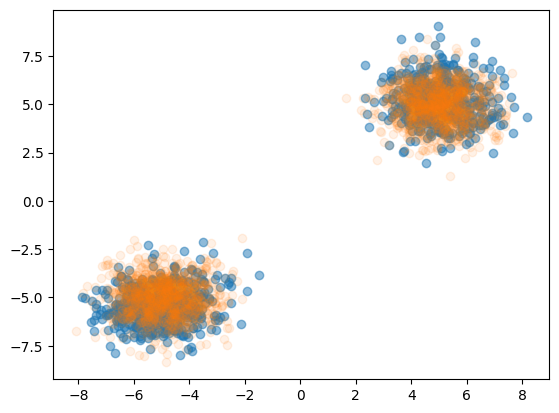

In [67]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)


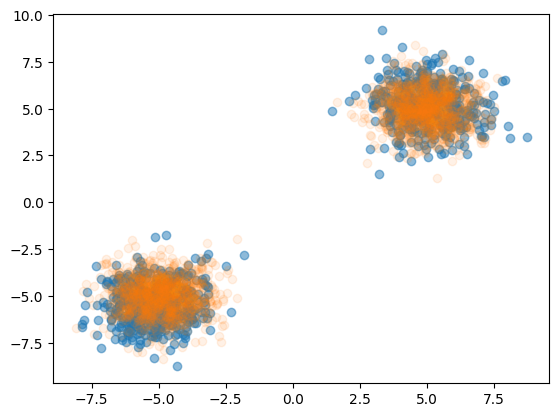

In [70]:
import matplotlib.pyplot as plt
samples_sde = sample_sde(params, jax.random.PRNGKey(0 ), (1000,), eps=1.1)
plt.scatter(samples_sde[:,0], samples_sde[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)


## Optimal transport flows

Works as above, but x0 and x1 cannot be sampled independently, but have to be sampled from the OT coupling!

In [ ]:
import ott

from ott.geometry import costs, pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn

x0 = jax.random.normal(jax.random.PRNGKey(0), xs.shape)
x1 = xs.copy()

geom = pointcloud.PointCloud(x0, x1, epsilon=1e-1)

In [ ]:
ot_prob = linear_problem.LinearProblem(geom)
# Create a Sinkhorn solver
solver = sinkhorn.Sinkhorn()
# Solve OT problem
ot = solver(ot_prob)

In [ ]:
index = ot.matrix.argmax(axis=1)
x1 = x1[index]

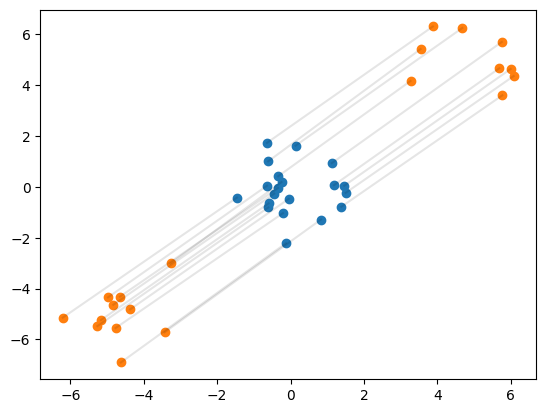

In [ ]:
plt.plot(x0[:20,0], x0[:20,1], "o")
plt.plot(x1[:20,0], x1[:20,1], "o")



_ = plt.plot([x0[:20,0], x1[:20,0]], [x0[:20,1], x1[:20,1]], color="black", alpha=0.1)

In [ ]:
sigma_min = 1e-2

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    key_source, key_time, key_loss = jax.random.split(key,3)
    xs_source = jax.random.normal(key_source, x1.shape)
    times = jax.random.uniform(key_time, (x1.shape[0], 1))
    
    geom = pointcloud.PointCloud(xs_source, x1, epsilon=1e-1)
    ot_prob = linear_problem.LinearProblem(geom)
    solver = sinkhorn.Sinkhorn()
    ot = solver(ot_prob)
    index = ot.matrix.argmax(axis=1)
    x1 = x1[index]
    
    return loss2(params, key_loss, times, xs_source, x1) 
    

optimizer = adam(1e-3)
opt_state = optimizer.init(params)
    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [ ]:
for i in range(1000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (100,))
    params, opt_state, loss = step(params, opt_state, jax.random.PRNGKey(i + 10000),xs_batch)
    if i % 100 == 0:
        print(loss)

78.02648
1.0880094
0.78224087
1.8948711
1.1192839
0.76793534
0.9635694
0.32331437
0.6831074
0.77428985


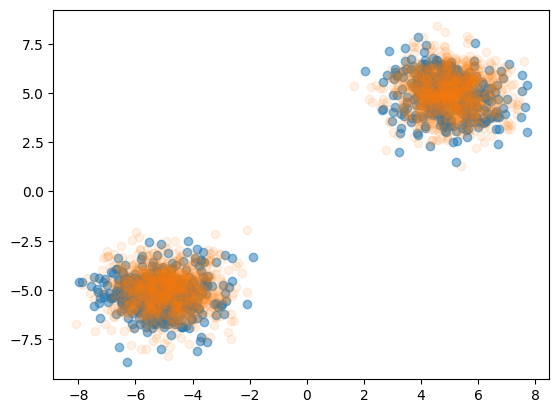

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(samples[:,0], samples[:,1], alpha=0.5)
plt.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

In [ ]:
evolution =  odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 200), method="rk4")

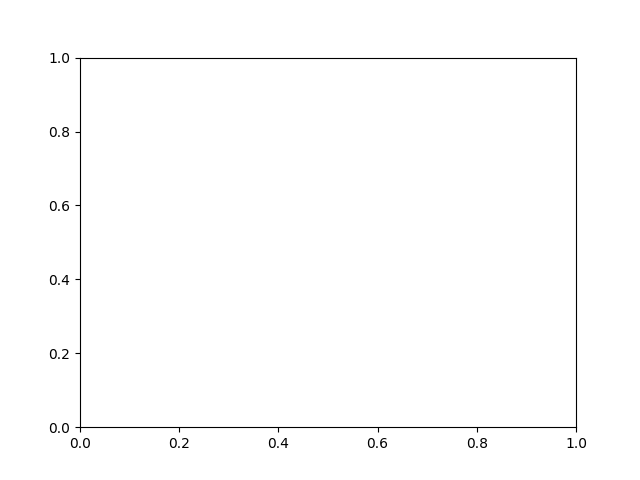

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()

def update(i):
    ax.clear()
    ax.scatter(evolution[i,:,0], evolution[i,:,1], alpha=0.5)
    ax.scatter(xs[:, 0], xs[:, 1], alpha=0.1)

ani = animation.FuncAnimation(fig, update, frames=range(0, 210, 10))

plt.show()